In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs(os.path.join("..", "outputs", "figures"), exist_ok=True)

In [3]:
df = pd.read_csv(os.path.join("..", "data", "uti_dataset.csv"), low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 80,387 rows × 220 columns


In [4]:
df.dtypes

ID               int64
PATID            int64
UCX_abnormal    object
ua_bacteria     object
ua_bili         object
                 ...  
dispo           object
UTI_diag        object
split           object
abxUTI          object
alt_diag         int64
Length: 220, dtype: object

In [5]:
df.head()

,ID,PATID,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity,ua_color,ua_epi,ua_glucose,...,SKIN_PREPS,SMOKING_DETERRENTS,THYROID_PREPS,UNCLASSIFIED_DRUG_PRODUCTS,VITAMINS,dispo,UTI_diag,split,abxUTI,alt_diag
0,1,1,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,No,No,No,Admit,Yes,training,yes,0
1,2,1,no,many,negative,small,clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
2,3,2,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,Yes,Yes,No,Discharge,No,training,no,0
3,4,3,yes,many,negative,negative,not_clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
4,5,4,no,moderate,small,negative,clear,orange,not_reported,negative,...,No,No,No,No,No,AMA,No,training,no,0


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,80387.0,NaN,NaN,NaN,40194.0,23205.872382,1.0,20097.5,40194.0,60290.5,80387.0
PATID,80387.0,NaN,NaN,NaN,27160.079602,16045.123111,1.0,13267.5,26693.0,40826.5,55365.0
UCX_abnormal,80387,2,no,62103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ua_bacteria,80387,6,not_reported,30225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ua_bili,80387,6,negative,71731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
dispo,80387,11,Discharge,42744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UTI_diag,80387,2,No,63221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,80387,2,training,64310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abxUTI,80387,2,yes,45151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count"  : missing,
    "missing_percent": missing_pct.round(2)
}).sort_values("missing_percent", ascending=False)

missing_nonzero = missing_report[missing_report["missing_count"] > 0]
print(f"Columns with missing values: {len(missing_nonzero)} out of {df.shape[1]}")
missing_nonzero

Columns with missing values: 0 out of 220


,missing_count,missing_percent


In [8]:
TARGET_COL = "UTI_diag"

counts   = df[TARGET_COL].value_counts()
percents = df[TARGET_COL].value_counts(normalize=True) * 100

dist = pd.DataFrame({"count": counts, "percent": percents.round(2)})
print(f"Imbalance ratio: {counts.max() / counts.min():.1f} : 1")
dist

Imbalance ratio: 3.7 : 1


,count,percent
UTI_diag,,
No,63221,78.65
Yes,17166,21.35


In [9]:
df["split"].value_counts()

split
training      64310
validation    16077
Name: count, dtype: int64

In [10]:
for col in ["Temp_First", "HR_First", "SBP_First"]:
    print(f"{col}: {sorted(df[col].unique())}")

Temp_First: ['1', '2', '3', '4', '5', 'not_reported']
HR_First: ['1', '2', '3', '4', '5', 'not_reported']
SBP_First: ['1', '2', '3', '4', '5', 'not_reported']


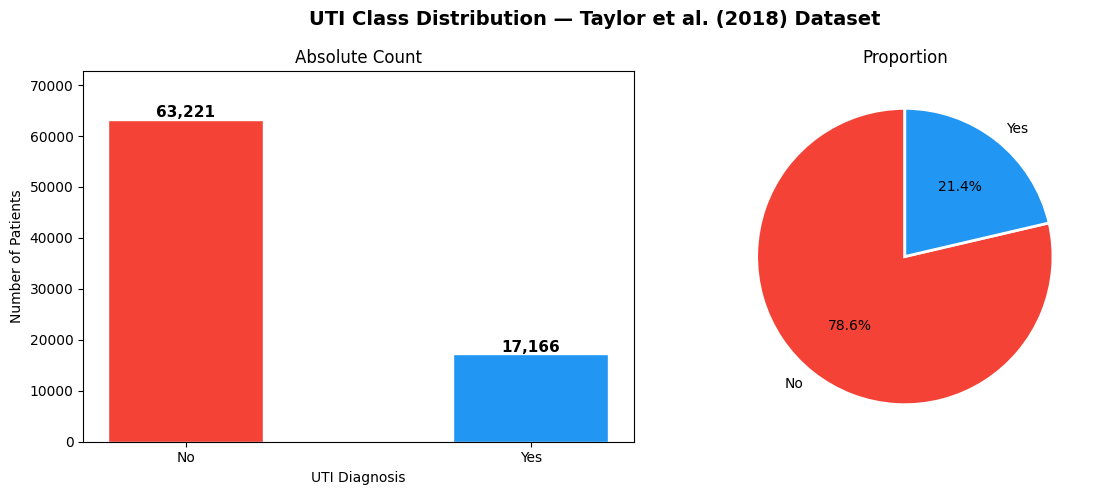

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("UTI Class Distribution — Taylor et al. (2018) Dataset",
             fontsize=14, fontweight="bold")

colors = ["#F44336", "#2196F3"]

bars = axes[0].bar(counts.index, counts.values,
                   color=colors, edgecolor="white", width=0.45)
axes[0].set_title("Absolute Count", fontsize=12)
axes[0].set_xlabel("UTI Diagnosis")
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, counts.max() * 1.15)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proportion", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "class_distribution.png"),
            dpi=150, bbox_inches="tight")

## Section 2 — Preprocessing

In [12]:
DROP_COLS = ["ID", "PATID", "split", "alt_diag", "abxUTI"]

df_clean = df.drop(columns=DROP_COLS)
print(f"Columns after dropping identifiers and leakage risks: {df_clean.shape[1]}")

Columns after dropping identifiers and leakage risks: 215


In [13]:
TARGET_COL = "UTI_diag"

X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL].map({"Yes": 1, "No": 0})

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape : (80387, 214)
Target shape   : (80387,)
Target distribution:
UTI_diag
0    63221
1    17166
Name: count, dtype: int64


In [14]:
# ua_ph looks numeric but loaded as object — fix it first
X["ua_ph"] = pd.to_numeric(X["ua_ph"], errors="coerce")

# Now split into categorical and numeric
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical columns : {len(cat_cols)}")
print(f"Numeric columns     : {len(num_cols)}")
print(f"\nCategorical columns:\n{cat_cols}")
print(f"\nNumeric columns:\n{num_cols}")

Categorical columns : 211
Numeric columns     : 3

Categorical columns:
['UCX_abnormal', 'ua_bacteria', 'ua_bili', 'ua_blood', 'ua_clarity', 'ua_color', 'ua_epi', 'ua_glucose', 'ua_ketones', 'ua_leuk', 'ua_nitrite', 'ua_protein', 'ua_rbc', 'ua_urobili', 'ua_wbc', 'CVA_tenderness', 'abd_tenderness', 'abd_soft', 'abd_distended', 'abd_gaurding', 'abd_mass', 'abd_rebound', 'abd_rigidity', 'back_pain', 'fatigue', 'fever', 'vag_bleeding', 'vag_discharge', 'abd_distended2', 'abd_pain', 'gen_neg', 'pelvic_pain', 'alert', 'ams', 'weakness', 'oriented', 'psychiatric_confusion', 'flank_pain', 'dec_urine_vol', 'diff_urinating', 'dysuria', 'hematuria', 'polyuria', 'chief_complaint', 'gender', 'race', 'ethnicity', 'lang', 'maritalStatus', 'employStatus', 'insurance_status', 'disposition', 'arrival', 'Temp_First', 'Temp_Last', 'Temp_Max', 'Temp_Min', 'Temp_Mean', 'HR_First', 'HR_Last', 'HR_Max', 'HR_Min', 'HR_Mean', 'SBP_First', 'SBP_Last', 'SBP_Max', 'SBP_Min', 'SBP_Mean', 'DBP_First', 'DBP_Last', '

In [15]:
# pd.to_numeric with errors="coerce" turns non-numeric strings into NaN
# Check how many NaNs were introduced in ua_ph
print(f"ua_ph null count after coercion: {X['ua_ph'].isnull().sum()}")

# Fill with median — appropriate for a skewed ordinal numeric column
ua_ph_median = X["ua_ph"].median()
X["ua_ph"] = X["ua_ph"].fillna(ua_ph_median)
print(f"ua_ph nulls after fill: {X['ua_ph'].isnull().sum()}")
print(f"ua_ph filled with median: {ua_ph_median}")

ua_ph null count after coercion: 127
ua_ph nulls after fill: 0
ua_ph filled with median: 6.0


In [16]:
from sklearn.preprocessing import LabelEncoder

# We use label encoding rather than one-hot encoding here because:
# 1. Many categorical columns are ordinal (e.g. vital sign bins 1-5)
# 2. Tree-based models like XGBoost handle integer-encoded categories natively
# 3. One-hot encoding 200+ categorical columns would massively expand dimensionality

le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Categorical encoding complete.")
print(f"\nSample encoded values:")
X[cat_cols[:5]].head()

Categorical encoding complete.

Sample encoded values:


,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity
0,1,0,2,2,0
1,0,1,2,5,0
2,1,0,2,2,0
3,1,1,2,2,1
4,0,3,5,2,0


In [17]:
null_check = X.isnull().sum().sum()
print(f"Total null values remaining in X: {null_check}")
print(f"Final feature matrix shape: {X.shape}")

Total null values remaining in X: 0
Final feature matrix shape: (80387, 214)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class ratio in both splits
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set   : 64,309 rows
Test set       : 16,078 rows

Training class distribution:
UTI_diag
0    50576
1    13733
Name: count, dtype: int64

Test class distribution:
UTI_diag
0    12645
1     3433
Name: count, dtype: int64


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Training shape : {X_train.shape}")
print(f"After SMOTE  — Training shape : {X_train_sm.shape}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE — Training shape : (64309, 214)
After SMOTE  — Training shape : (101152, 214)

Class distribution after SMOTE:
UTI_diag
0    50576
1    50576
Name: count, dtype: int64


In [20]:
import json

feature_cols = X.columns.tolist()

with open(os.path.join("..", "outputs", "feature_cols.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

print(f"Saved {len(feature_cols)} feature column names to outputs/feature_cols.json")

Saved 214 feature column names to outputs/feature_cols.json


## Section 3 — Baseline Model: Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

In [22]:
lr = LogisticRegression(
    max_iter=1000,        # default 100 often fails to converge on large datasets
    random_state=42,
    n_jobs=-1             # use all CPU cores
)

lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [23]:
y_pred_lr    = lr.predict(X_test)
y_proba_lr   = lr.predict_proba(X_test)[:, 1]  # probability of UTI-positive

In [24]:
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"Logistic Regression AUC-ROC: {auc_lr:.4f}")

Logistic Regression AUC-ROC: 0.8747


In [25]:
print("Classification Report — Logistic Regression")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=["UTI-Negative", "UTI-Positive"]))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

UTI-Negative       0.91      0.85      0.88     12645
UTI-Positive       0.55      0.68      0.61      3433

    accuracy                           0.81     16078
   macro avg       0.73      0.76      0.74     16078
weighted avg       0.83      0.81      0.82     16078



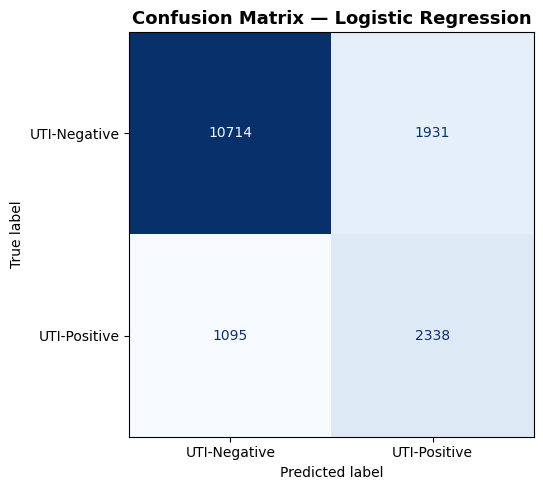

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=["UTI-Negative", "UTI-Positive"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "cm_logistic_regression.png"),
            dpi=150, bbox_inches="tight")

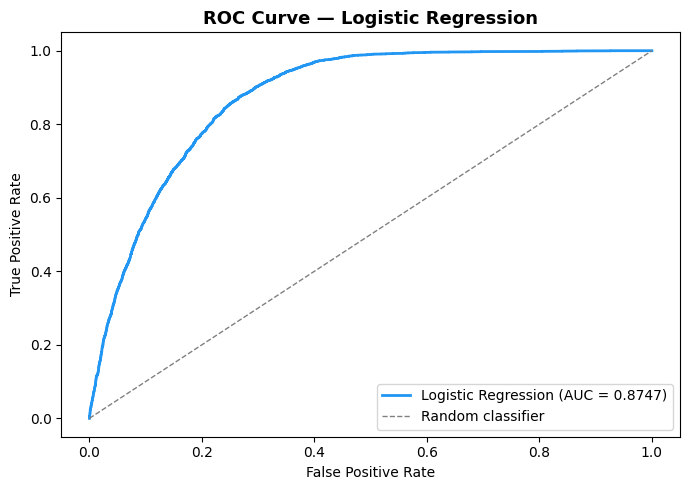

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#2196F3", lw=2,
        label=f"Logistic Regression (AUC = {auc_lr:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "roc_logistic_regression.png"),
            dpi=150, bbox_inches="tight")

In [28]:
results = {}

results["Logistic Regression"] = {
    "AUC-ROC"  : round(auc_lr, 4),
    "Precision": round(float(classification_report(y_test, y_pred_lr, output_dict=True)["1"]["precision"]), 4),
    "Recall"   : round(float(classification_report(y_test, y_pred_lr, output_dict=True)["1"]["recall"]), 4),
    "F1-Score" : round(float(classification_report(y_test, y_pred_lr, output_dict=True)["1"]["f1-score"]), 4),
}

print("Results saved:")
results

Results saved:


{'Logistic Regression': {'AUC-ROC': 0.8747,
  'Precision': 0.5477,
  'Recall': 0.681,
  'F1-Score': 0.6071}}

## Section 4 — Primary Model: XGBoost (Full Features)

In [29]:
from xgboost import XGBClassifier

In [30]:
xgb_full = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_full.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50           # prints AUC every 50 trees so you can watch it converge
)

print("\nXGBoost training complete.")

C:\Users\hp\Documents\Files\Python\Machine Learning Projects\UTI_study\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:38:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-auc:0.77521
[50]	validation_0-auc:0.89546
[100]	validation_0-auc:0.90718
[150]	validation_0-auc:0.91366
[200]	validation_0-auc:0.91739
[250]	validation_0-auc:0.92024
[299]	validation_0-auc:0.92200

XGBoost training complete.


In [31]:
y_pred_xgb_full  = xgb_full.predict(X_test)
y_proba_xgb_full = xgb_full.predict_proba(X_test)[:, 1]

In [32]:
auc_xgb_full = roc_auc_score(y_test, y_proba_xgb_full)
print(f"XGBoost Full Features AUC-ROC: {auc_xgb_full:.4f}")

XGBoost Full Features AUC-ROC: 0.9220


In [33]:
print("Classification Report — XGBoost Full Features")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb_full,
                             target_names=["UTI-Negative", "UTI-Positive"]))

Classification Report — XGBoost Full Features
              precision    recall  f1-score   support

UTI-Negative       0.91      0.91      0.91     12645
UTI-Positive       0.68      0.68      0.68      3433

    accuracy                           0.86     16078
   macro avg       0.80      0.80      0.80     16078
weighted avg       0.86      0.86      0.86     16078



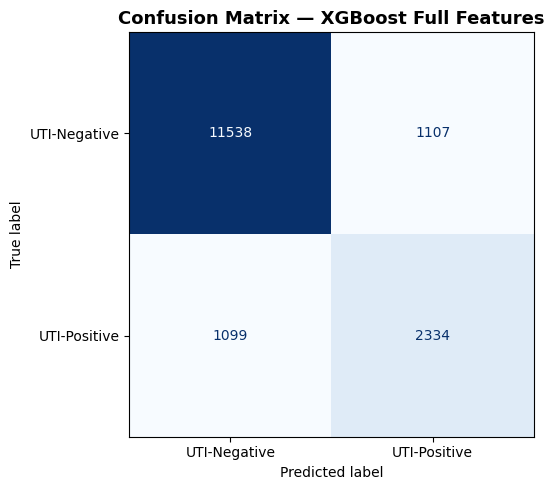

In [34]:
cm_xgb_full = confusion_matrix(y_test, y_pred_xgb_full)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_full,
                               display_labels=["UTI-Negative", "UTI-Positive"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost Full Features",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "cm_xgb_full.png"),
            dpi=150, bbox_inches="tight")

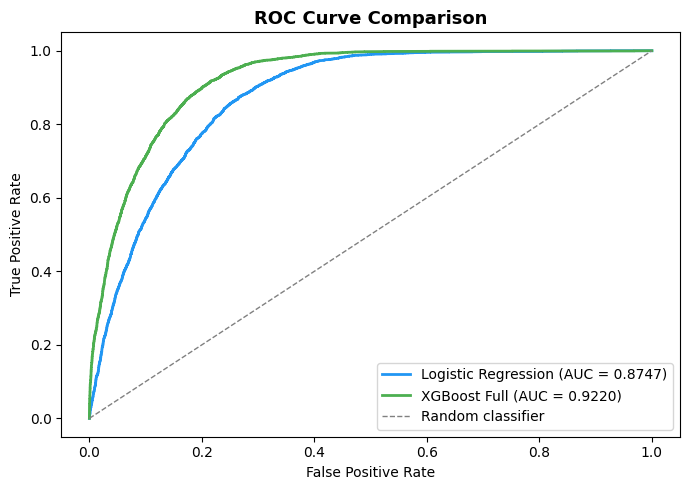

In [35]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb_full)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color="#2196F3", lw=2,
        label=f"Logistic Regression (AUC = {auc_lr:.4f})")
ax.plot(fpr_xgb, tpr_xgb, color="#4CAF50", lw=2,
        label=f"XGBoost Full (AUC = {auc_xgb_full:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
        label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "roc_comparison_stage5.png"),
            dpi=150, bbox_inches="tight")

In [36]:
xgb_full_report = classification_report(y_test, y_pred_xgb_full, output_dict=True)

results["XGBoost Full"] = {
    "AUC-ROC"  : round(auc_xgb_full, 4),
    "Precision": round(float(xgb_full_report["1"]["precision"]), 4),
    "Recall"   : round(float(xgb_full_report["1"]["recall"]), 4),
    "F1-Score" : round(float(xgb_full_report["1"]["f1-score"]), 4),
}

print("Results saved:")
results

Results saved:


{'Logistic Regression': {'AUC-ROC': 0.8747,
  'Precision': 0.5477,
  'Recall': 0.681,
  'F1-Score': 0.6071},
 'XGBoost Full': {'AUC-ROC': 0.922,
  'Precision': 0.6783,
  'Recall': 0.6799,
  'F1-Score': 0.6791}}

## Section 5 — Feature Selection: XGBoost Importance + SHAP

In [37]:
import shap
import json

In [38]:
importance_gain = xgb_full.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature"   : list(importance_gain.keys()),
    "gain_score": list(importance_gain.values())
}).sort_values("gain_score", ascending=False).reset_index(drop=True)

importance_df["gain_rank"] = importance_df.index + 1

print(f"Features with non-zero importance: {len(importance_df)} out of {X_train_sm.shape[1]}")
importance_df.head(20)

Features with non-zero importance: 199 out of 214


,feature,gain_score,gain_rank
0,abx,1397.321899,1
1,ANTIBIOTICS,436.767151,2
2,ua_wbc,228.750015,3
3,ANTIARTHRITICS,120.504341,4
4,ANTIASTHMATICS,115.853958,5
5,ua_bacteria,99.791130,6
6,ua_ph,90.849678,7
7,ANALGESICS,87.554955,8
8,RR_Max,86.821075,9
9,ua_clarity,77.053024,10


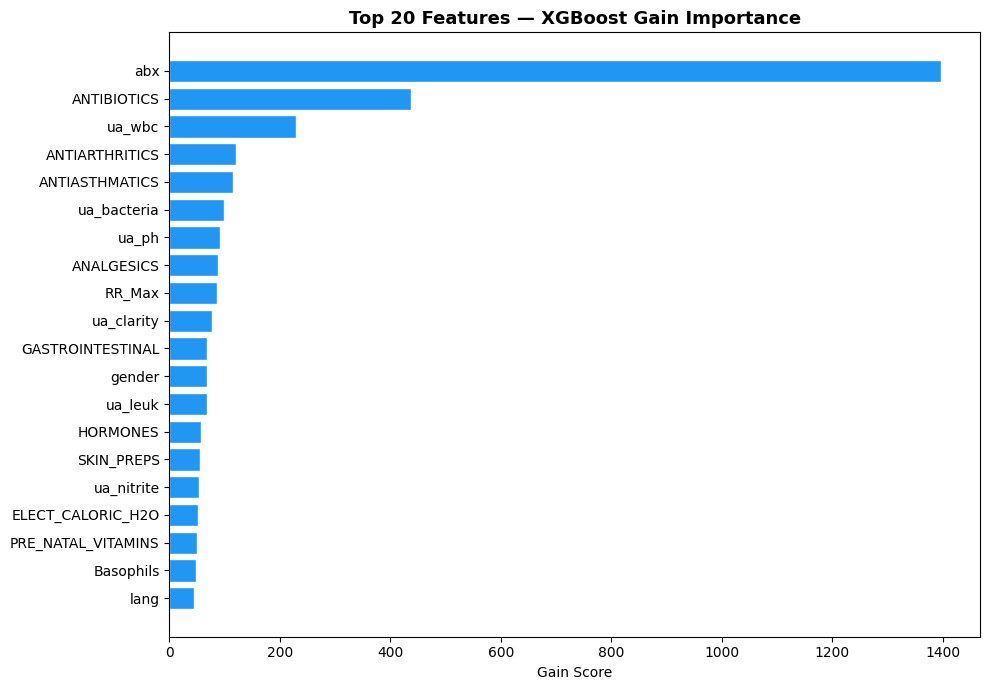

In [39]:
top20_gain = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_gain["feature"][::-1],
    top20_gain["gain_score"][::-1],
    color="#2196F3", edgecolor="white"
)
ax.set_xlabel("Gain Score")
ax.set_title("Top 20 Features — XGBoost Gain Importance",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "xgb_gain_importance.png"),
            dpi=150, bbox_inches="tight")

In [40]:
explainer    = shap.TreeExplainer(xgb_full)
shap_values  = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (16078, 214)


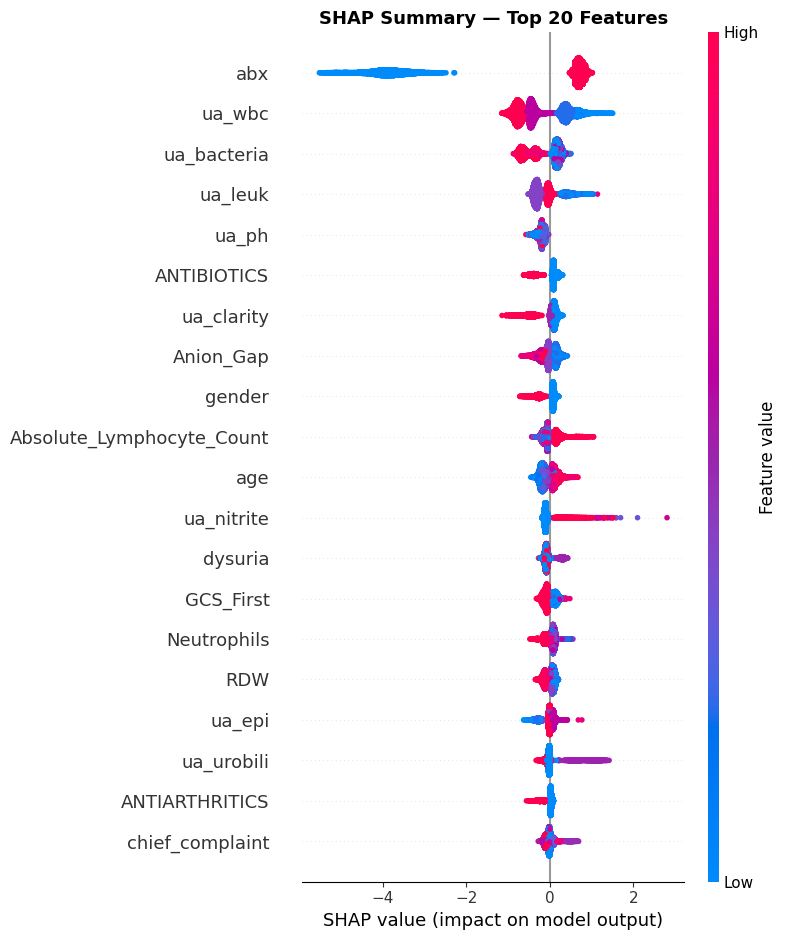

In [41]:
shap.summary_plot(
    shap_values, X_test,
    max_display=20,
    show=False
)

plt.title("SHAP Summary — Top 20 Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "shap_summary_beeswarm.png"),
            dpi=150, bbox_inches="tight")
plt.show()

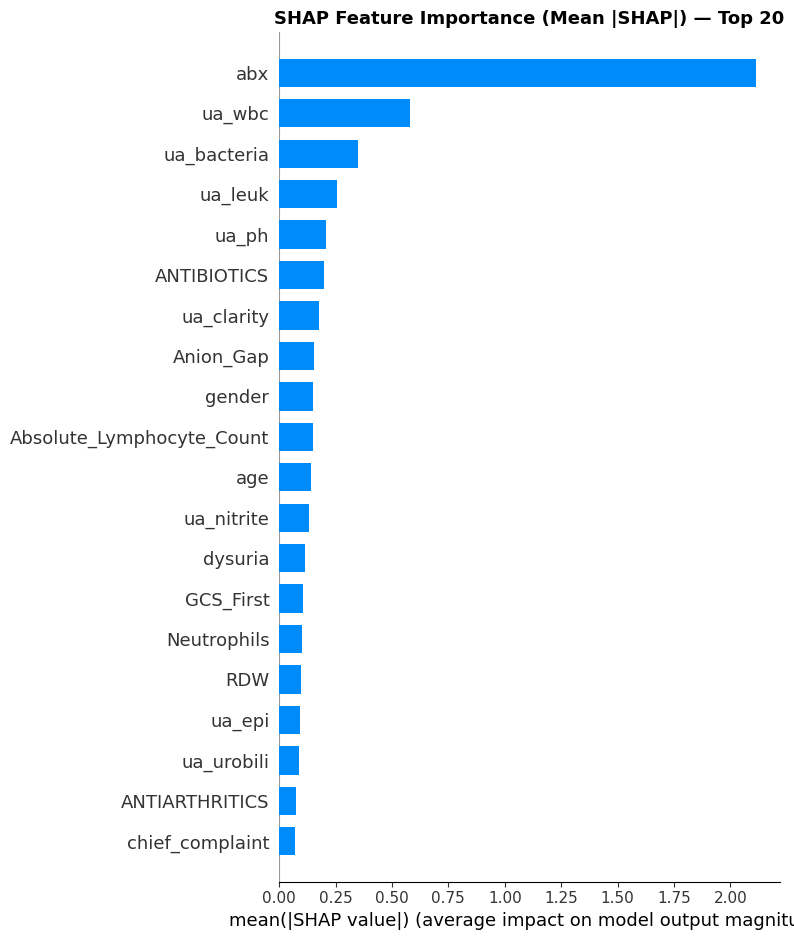

In [42]:
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance (Mean |SHAP|) — Top 20",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "shap_bar.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [43]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature"   : X_test.columns.tolist(),
    "mean_shap" : mean_shap
}).sort_values("mean_shap", ascending=False).reset_index(drop=True)

shap_df["shap_rank"] = shap_df.index + 1

print("Top 20 features by SHAP:")
shap_df.head(20)

Top 20 features by SHAP:


,feature,mean_shap,shap_rank
0,abx,2.114425,1
1,ua_wbc,0.578830,2
2,ua_bacteria,0.350844,3
3,ua_leuk,0.255864,4
4,ua_ph,0.208560,5
5,ANTIBIOTICS,0.198373,6
6,ua_clarity,0.174917,7
7,Anion_Gap,0.156867,8
8,gender,0.149806,9
9,Absolute_Lymphocyte_Count,0.149078,10


In [44]:
combined = importance_df[["feature", "gain_score", "gain_rank"]].merge(
    shap_df[["feature", "mean_shap", "shap_rank"]],
    on="feature",
    how="inner"
)

combined["combined_rank"] = (combined["gain_rank"] + combined["shap_rank"]) / 2
combined = combined.sort_values("combined_rank").reset_index(drop=True)

print("Top 20 features by combined gain + SHAP ranking:")
combined.head(20)

Top 20 features by combined gain + SHAP ranking:


,feature,gain_score,gain_rank,mean_shap,shap_rank,combined_rank
0,abx,1397.321899,1,2.114425,1,1.0
1,ua_wbc,228.750015,3,0.578830,2,2.5
2,ANTIBIOTICS,436.767151,2,0.198373,6,4.0
3,ua_bacteria,99.791130,6,0.350844,3,4.5
4,ua_ph,90.849678,7,0.208560,5,6.0
5,ua_leuk,67.354019,13,0.255864,4,8.5
6,ua_clarity,77.053024,10,0.174917,7,8.5
7,gender,68.483841,12,0.149806,9,10.5
8,ANTIARTHRITICS,120.504341,4,0.076301,19,11.5
9,ua_nitrite,54.173557,16,0.133095,12,14.0


In [45]:
# Select top 15 by combined ranking
N_FEATURES = 15

selected_features = combined.head(N_FEATURES)["feature"].tolist()

print(f"Selected {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:>2}. {f}")

Selected 15 features:
   1. abx
   2. ua_wbc
   3. ANTIBIOTICS
   4. ua_bacteria
   5. ua_ph
   6. ua_leuk
   7. ua_clarity
   8. gender
   9. ANTIARTHRITICS
  10. ua_nitrite
  11. ANTIASTHMATICS
  12. Anion_Gap
  13. ua_urobili
  14. dysuria
  15. ANALGESICS


In [46]:
with open(os.path.join("..", "outputs", "selected_features.json"), "w") as f:
    json.dump(selected_features, f, indent=2)

print(f"Saved {len(selected_features)} selected features to outputs/selected_features.json")

Saved 15 selected features to outputs/selected_features.json


## Section 6 — Reduced Feature Model: XGBoost (Top 15 Features)

In [47]:
X_train_reduced = X_train_sm[selected_features]
X_test_reduced  = X_test[selected_features]

print(f"Reduced training set : {X_train_reduced.shape}")
print(f"Reduced test set     : {X_test_reduced.shape}")

Reduced training set : (101152, 15)
Reduced test set     : (16078, 15)


In [48]:
xgb_reduced = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_reduced.fit(
    X_train_reduced, y_train_sm,
    eval_set=[(X_test_reduced, y_test)],
    verbose=50
)

print("\nXGBoost Reduced training complete.")

[0]	validation_0-auc:0.86671
[50]	validation_0-auc:0.89159
[100]	validation_0-auc:0.89934
[150]	validation_0-auc:0.90288
[200]	validation_0-auc:0.90435
[250]	validation_0-auc:0.90513
[299]	validation_0-auc:0.90536

XGBoost Reduced training complete.


In [49]:
y_pred_xgb_reduced  = xgb_reduced.predict(X_test_reduced)
y_proba_xgb_reduced = xgb_reduced.predict_proba(X_test_reduced)[:, 1]

In [50]:
auc_xgb_reduced = roc_auc_score(y_test, y_proba_xgb_reduced)
print(f"XGBoost Reduced Features AUC-ROC: {auc_xgb_reduced:.4f}")

XGBoost Reduced Features AUC-ROC: 0.9054


In [51]:
print("Classification Report — XGBoost Reduced Features")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb_reduced,
                             target_names=["UTI-Negative", "UTI-Positive"]))

Classification Report — XGBoost Reduced Features
              precision    recall  f1-score   support

UTI-Negative       0.91      0.88      0.90     12645
UTI-Positive       0.62      0.70      0.65      3433

    accuracy                           0.84     16078
   macro avg       0.77      0.79      0.78     16078
weighted avg       0.85      0.84      0.85     16078



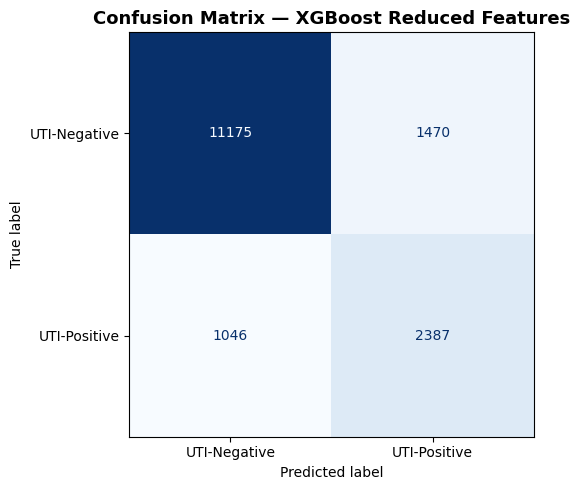

In [52]:
cm_xgb_reduced = confusion_matrix(y_test, y_pred_xgb_reduced)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_reduced,
                               display_labels=["UTI-Negative", "UTI-Positive"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost Reduced Features",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "cm_xgb_reduced.png"),
            dpi=150, bbox_inches="tight")

In [53]:
xgb_reduced_report = classification_report(
    y_test, y_pred_xgb_reduced, output_dict=True
)

results["XGBoost Reduced"] = {
    "AUC-ROC"  : round(auc_xgb_reduced, 4),
    "Precision": round(float(xgb_reduced_report["1"]["precision"]), 4),
    "Recall"   : round(float(xgb_reduced_report["1"]["recall"]), 4),
    "F1-Score" : round(float(xgb_reduced_report["1"]["f1-score"]), 4),
}

print("Results saved.")

Results saved.


In [54]:
comparison_df = pd.DataFrame(results).T
comparison_df.index.name = "Model"

# Add Taylor et al. benchmark as reference row
taylor_benchmark = pd.DataFrame([{
    "AUC-ROC"  : 0.960,
    "Precision": "-",
    "Recall"   : "-",
    "F1-Score" : "-"
}], index=["Taylor et al. (2018)"])

comparison_df = pd.concat([comparison_df, taylor_benchmark])
print("Three-way comparison vs Taylor et al. (2018) benchmark:")
comparison_df

Three-way comparison vs Taylor et al. (2018) benchmark:


,AUC-ROC,Precision,Recall,F1-Score
Logistic Regression,0.8747,0.5477,0.681,0.6071
XGBoost Full,0.9220,0.6783,0.6799,0.6791
XGBoost Reduced,0.9054,0.6189,0.6953,0.6549
Taylor et al. (2018),0.9600,-,-,-


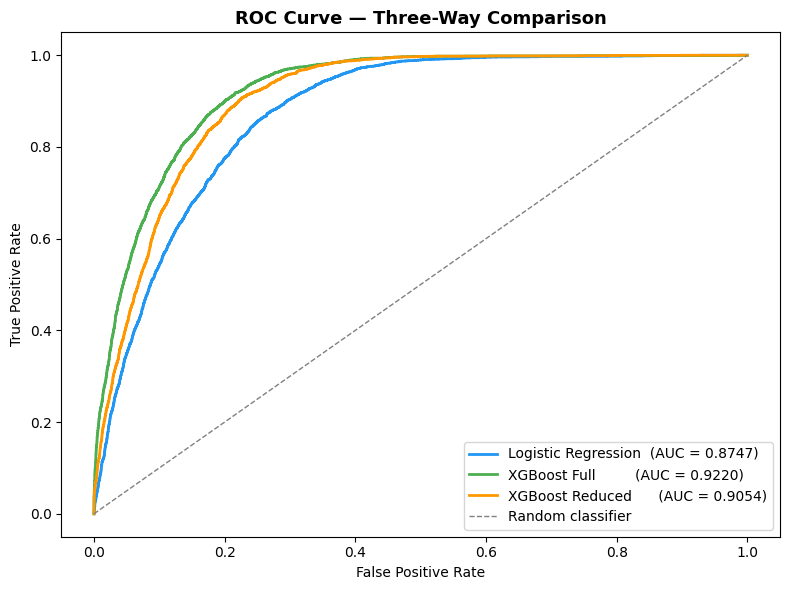

In [55]:
fpr_red, tpr_red, _ = roc_curve(y_test, y_proba_xgb_reduced)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color="#2196F3", lw=2,
        label=f"Logistic Regression  (AUC = {auc_lr:.4f})")
ax.plot(fpr_xgb, tpr_xgb, color="#4CAF50", lw=2,
        label=f"XGBoost Full         (AUC = {auc_xgb_full:.4f})")
ax.plot(fpr_red, tpr_red, color="#FF9800", lw=2,
        label=f"XGBoost Reduced      (AUC = {auc_xgb_reduced:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
        label="Random classifier")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Three-Way Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "roc_comparison_final.png"),
            dpi=150, bbox_inches="tight")

In [56]:
import joblib

model_path = os.path.join("..", "outputs", "models", "model.pkl")
joblib.dump(xgb_reduced, model_path)

print(f"Model saved to {model_path}")

Model saved to ..\outputs\models\model.pkl


In [57]:
model_check = joblib.load(model_path)
test_pred   = model_check.predict(X_test_reduced[:5])
print(f"Verification predictions: {test_pred}")
print("Model serialisation verified.")

Verification predictions: [0 0 1 1 0]
Model serialisation verified.


In [58]:
from sklearn.preprocessing import LabelEncoder
import json

# Rebuild the exact encoding the model was trained on
# by refitting LabelEncoder on the original data for each selected feature
encoding_map = {}

for feature in selected_features:
    le = LabelEncoder()
    le.fit(X[feature].astype(str))
    encoding_map[feature] = {
        label: int(idx) for idx, label in enumerate(le.classes_)
    }

# Print the mapping for every selected feature
for feature, mapping in encoding_map.items():
    print(f"\n{feature}:")
    for label, code in sorted(mapping.items(), key=lambda x: x[1]):
        print(f"  {code} → '{label}'")

# Save the encoding map so the app can use it directly
with open(os.path.join("..", "outputs", "encoding_map.json"), "w") as f:
    json.dump(encoding_map, f, indent=2)

print("\nEncoding map saved to outputs/encoding_map.json")


abx:
  0 → '0'
  1 → '1'

ua_wbc:
  0 → '0'
  1 → '1'
  2 → '2'
  3 → '3'
  4 → '4'
  5 → '5'

ANTIBIOTICS:
  0 → '0'
  1 → '1'

ua_bacteria:
  0 → '0'
  1 → '1'
  2 → '2'
  3 → '3'
  4 → '4'
  5 → '5'

ua_ph:
  0 → '5.0'
  1 → '5.5'
  2 → '6.0'
  3 → '6.5'
  4 → '7.0'
  5 → '7.5'
  6 → '8.0'
  7 → '8.5'
  8 → '9.0'

ua_leuk:
  0 → '0'
  1 → '1'
  2 → '2'
  3 → '3'
  4 → '4'
  5 → '5'

ua_clarity:
  0 → '0'
  1 → '1'
  2 → '2'

gender:
  0 → '0'
  1 → '1'
  2 → '2'

ANTIARTHRITICS:
  0 → '0'
  1 → '1'

ua_nitrite:
  0 → '0'
  1 → '1'
  2 → '2'
  3 → '3'

ANTIASTHMATICS:
  0 → '0'
  1 → '1'

Anion_Gap:
  0 → '0'
  1 → '1'
  2 → '2'
  3 → '3'
  4 → '4'
  5 → '5'

ua_urobili:
  0 → '0'
  1 → '1'
  2 → '2'

dysuria:
  0 → '0'
  1 → '1'
  2 → '2'

ANALGESICS:
  0 → '0'
  1 → '1'

Encoding map saved to outputs/encoding_map.json


In [59]:
for feature in selected_features:
    unique_vals = sorted(df[feature].astype(str).unique())
    print(f"\n{feature} ({len(unique_vals)} unique values):")
    print(f"  {unique_vals}")


abx (2 unique values):
  ['No', 'Yes']

ua_wbc (6 unique values):
  ['large', 'moderate', 'negative', 'not_reported', 'other', 'small']

ANTIBIOTICS (2 unique values):
  ['No', 'Yes']

ua_bacteria (6 unique values):
  ['few', 'many', 'marked', 'moderate', 'none', 'not_reported']

ua_ph (11 unique values):
  ['5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0', 'not_reported', 'other']

ua_leuk (6 unique values):
  ['large', 'moderate', 'negative', 'not_reported', 'other', 'small']

ua_clarity (3 unique values):
  ['clear', 'not_clear', 'not_reported']

gender (3 unique values):
  ['Female', 'Male', 'not_reported']

ANTIARTHRITICS (2 unique values):
  ['No', 'Yes']

ua_nitrite (4 unique values):
  ['negative', 'not_reported', 'other', 'positive']

ANTIASTHMATICS (2 unique values):
  ['No', 'Yes']

Anion_Gap (6 unique values):
  ['1', '2', '3', '4', '5', 'not_reported']

ua_urobili (3 unique values):
  ['negative', 'not_reported', 'positive']

dysuria (3 unique values):
  ['0'

In [60]:
with open(os.path.join("..", "outputs", "encoding_map.json"), "r") as f:
    enc = json.load(f)

for feature in selected_features:
    print(f"\n{feature}:")
    print(f"  {enc[feature]}")


abx:
  {'0': 0, '1': 1}

ua_wbc:
  {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}

ANTIBIOTICS:
  {'0': 0, '1': 1}

ua_bacteria:
  {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}

ua_ph:
  {'5.0': 0, '5.5': 1, '6.0': 2, '6.5': 3, '7.0': 4, '7.5': 5, '8.0': 6, '8.5': 7, '9.0': 8}

ua_leuk:
  {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}

ua_clarity:
  {'0': 0, '1': 1, '2': 2}

gender:
  {'0': 0, '1': 1, '2': 2}

ANTIARTHRITICS:
  {'0': 0, '1': 1}

ua_nitrite:
  {'0': 0, '1': 1, '2': 2, '3': 3}

ANTIASTHMATICS:
  {'0': 0, '1': 1}

Anion_Gap:
  {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}

ua_urobili:
  {'0': 0, '1': 1, '2': 2}

dysuria:
  {'0': 0, '1': 1, '2': 2}

ANALGESICS:
  {'0': 0, '1': 1}


In [61]:
encoding_map_fixed = {}

for feature in selected_features:
    # Get the original raw string values from df (before any encoding)
    raw_vals = sorted(df[feature].astype(str).unique())
    # LabelEncoder assigns integers alphabetically — replicate that exactly
    encoding_map_fixed[feature] = {
        label: int(idx) for idx, label in enumerate(raw_vals)
    }

# Verify it looks right
for feature, mapping in encoding_map_fixed.items():
    print(f"\n{feature}:")
    for label, code in mapping.items():
        print(f"  '{label}' → {code}")

# Overwrite the old encoding map
with open(os.path.join("..", "outputs", "encoding_map.json"), "w") as f:
    json.dump(encoding_map_fixed, f, indent=2)

print("\nFixed encoding map saved.")


abx:
  'No' → 0
  'Yes' → 1

ua_wbc:
  'large' → 0
  'moderate' → 1
  'negative' → 2
  'not_reported' → 3
  'other' → 4
  'small' → 5

ANTIBIOTICS:
  'No' → 0
  'Yes' → 1

ua_bacteria:
  'few' → 0
  'many' → 1
  'marked' → 2
  'moderate' → 3
  'none' → 4
  'not_reported' → 5

ua_ph:
  '5.0' → 0
  '5.5' → 1
  '6.0' → 2
  '6.5' → 3
  '7.0' → 4
  '7.5' → 5
  '8.0' → 6
  '8.5' → 7
  '9.0' → 8
  'not_reported' → 9
  'other' → 10

ua_leuk:
  'large' → 0
  'moderate' → 1
  'negative' → 2
  'not_reported' → 3
  'other' → 4
  'small' → 5

ua_clarity:
  'clear' → 0
  'not_clear' → 1
  'not_reported' → 2

gender:
  'Female' → 0
  'Male' → 1
  'not_reported' → 2

ANTIARTHRITICS:
  'No' → 0
  'Yes' → 1

ua_nitrite:
  'negative' → 0
  'not_reported' → 1
  'other' → 2
  'positive' → 3

ANTIASTHMATICS:
  'No' → 0
  'Yes' → 1

Anion_Gap:
  '1' → 0
  '2' → 1
  '3' → 2
  '4' → 3
  '5' → 4
  'not_reported' → 5

ua_urobili:
  'negative' → 0
  'not_reported' → 1
  'positive' → 2

dysuria:
  '0' → 0
  '1' →